In [61]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

In [62]:
df = pd.read_csv(r"C:\Users\91984\Downloads\TCS_historical_data_Daily_10_Years.csv")

In [63]:
df1 = pd.read_csv(r"C:\Users\91984\Downloads\TCS_historical_data_Daily_Full_History.csv")

In [64]:
df

,Date,Open,High,Low,Close,Volume,Exchange
0,2025-10-03,2924.00,2924.00,2891.10,2903.00,2799767,NSE
1,2025-10-01,2891.00,2924.80,2866.60,2916.80,1941068,NSE
2,2025-09-30,2911.00,2915.30,2885.10,2894.90,2228350,NSE
3,2025-09-29,2916.00,2929.30,2894.00,2904.30,3084635,NSE
4,2025-09-26,2941.00,2954.80,2891.30,2905.40,3876112,NSE
...,...,...,...,...,...,...,...
2458,2015-10-28,1255.03,1266.78,1255.03,1264.55,1255342,NSE
2459,2015-10-27,1265.03,1272.45,1260.18,1265.55,1530420,NSE
2460,2015-10-26,1274.50,1274.50,1257.55,1268.28,1414630,NSE
2461,2015-10-23,1274.00,1274.00,1263.65,1268.58,2335398,NSE


In [65]:
df1

,Date,Open,High,Low,Close,Volume,Exchange
0,2025-09-23,3070.00,3080.70,3052.00,3065.00,3055485,NSE
1,2025-09-22,3095.00,3106.90,3065.00,3075.50,2914607,NSE
2,2025-09-19,3170.00,3180.50,3144.00,3171.00,4883224,NSE
3,2025-09-18,3185.00,3203.00,3161.40,3177.00,2613572,NSE
4,2025-09-17,3152.00,3182.40,3142.40,3175.00,2409180,NSE
...,...,...,...,...,...,...,...
5207,2004-08-31,121.42,121.85,120.13,121.62,21194656,NSE
5208,2004-08-30,119.38,121.85,118.78,121.45,24465208,NSE
5209,2004-08-27,120.92,120.92,117.98,118.49,30646000,NSE
5210,2004-08-26,122.10,122.71,120.04,120.50,40443200,NSE


In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2463 entries, 0 to 2462
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Date      2463 non-null   object 
 1   Open      2463 non-null   float64
 2   High      2463 non-null   float64
 3   Low       2463 non-null   float64
 4   Close     2463 non-null   float64
 5   Volume    2463 non-null   int64  
 6   Exchange  2463 non-null   object 
dtypes: float64(4), int64(1), object(2)
memory usage: 134.8+ KB


In [67]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Exchange'], dtype='object')

In [68]:
# df['Date '] = pd.to_datetime(df['Date '])

In [69]:
df.drop(columns=['Exchange'],inplace=True)

In [70]:
df1.drop(columns=['Exchange'],inplace=True)

In [71]:
df.describe()

,Open,High,Low,Close,Volume
count,2463.000000,2463.000000,2463.000000,2463.000000,2.463000e+03
mean,2585.905826,2610.474693,2560.201230,2584.980832,2.678150e+06
std,1018.061389,1025.963757,1009.972351,1017.444424,2.388465e+06
min,1058.450000,1070.000000,1025.950000,1050.580000,6.505700e+04
25%,1606.915000,1698.315000,1578.240000,1645.275000,1.650828e+06
50%,2661.000000,2689.000000,2627.550000,2660.250000,2.238097e+06
75%,3435.000000,3464.850000,3410.950000,3440.875000,3.089852e+06
max,4576.000000,4592.250000,4512.000000,4553.750000,8.806715e+07


In [72]:
df=df.copy(deep=True)
col=['Open', 'High', 'Low', 'Close', 'Volume']

In [73]:
df=df1.copy(deep=True)

In [74]:
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

In [75]:
df1['Date'] = pd.to_datetime(df1['Date'])
df1.set_index('Date', inplace=True)

In [76]:
for i in col:
    q25,q75=np.percentile(df[i],25),np.percentile(df[i],75)
    IQR = q75 - q25
    Threshold=IQR*1.5
    lower,upper=q25-Threshold,q75+Threshold
    outliers=[j for j in df[i] if j < lower or j > upper]
    for k in outliers:
        df=df.drop(df.index[df[i]==k],axis=0)

In [77]:
for i in col:
    q25,q75=np.percentile(df1[i],25),np.percentile(df1[i],75)
    IQR = q75 - q25
    Threshold=IQR*1.5
    lower,upper=q25-Threshold,q75+Threshold
    outliers=[j for j in df1[i] if j < lower or j > upper]
    for k in outliers:
        df1=df1.drop(df1.index[df1[i]==k],axis=0)

In [78]:
from sklearn.preprocessing import MinMaxScaler
features = ['Open', 'High', 'Low', 'Volume']
scalerx = MinMaxScaler()
scalery = MinMaxScaler()

In [79]:
scalerx1 = MinMaxScaler()
scalery1 = MinMaxScaler()

In [80]:
X=scalerx.fit_transform(df[features])

In [81]:
X1=scalerx1.fit_transform(df1[features])

In [82]:
Y=scalery.fit_transform(df[["Close"]])

In [83]:
Y1=scalery1.fit_transform(df1[["Close"]])

In [84]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest = train_test_split(X,Y,train_size=0.8,random_state=42)

In [85]:
xtrain1,xtest1,ytrain1,ytest1 = train_test_split(X1,Y1,train_size=0.8,random_state=42)

In [86]:
xtrain_reshaped = np.reshape(xtrain, (xtrain.shape[0],1, xtrain.shape[1]))

In [87]:
xtrain_reshaped1 = np.reshape(xtrain1, (xtrain1.shape[0],1, xtrain1.shape[1]))

In [88]:
from keras.models import Sequential
import tensorflow as tf
from tensorflow.keras.layers import Dense, Dropout, Conv1D, MaxPooling1D, Flatten

# Build CNN model
model_cnn = Sequential()

# 1D Convolution layer
model_cnn.add(Conv1D(
    filters=64,
    kernel_size=1,
    activation='relu',
    input_shape=(1, 4)
))

# Max pooling (optional — kept for structure)
model_cnn.add(MaxPooling1D(pool_size=1))

# Dropout
model_cnn.add(Dropout(0.2))

# Flatten to feed Dense layers
model_cnn.add(Flatten())

# Dense layer
model_cnn.add(Dense(32, activation='relu'))
model_cnn.add(Dropout(0.2))

# Output layer — regression
model_cnn.add(Dense(1, activation='linear'))

# Compile
model_cnn.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mse', tf.keras.metrics.MeanAbsolutePercentageError(), 'mae']
)

# Early stop condition
max_mae = 0.005

class StopCond(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        mae = logs.get('mae')
        if mae is not None and mae < max_mae:
            print(f"MAE threshold condition satisfied: {mae:.6f} < {max_mae}")
            self.model.stop_training = True

early_stop = StopCond()

# Fit model
history = model_cnn.fit(
    xtrain_reshaped, ytrain,
    epochs=200,
    batch_size=32,
    validation_split=0.1,
    verbose=1,
    callbacks=[early_stop]
)

Epoch 1/200
110/110 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - loss: 0.0282 - mae: 0.1088 - mean_absolute_percentage_error: 150.6172 - mse: 0.0282 - val_loss: 0.0012 - val_mae: 0.0275 - val_mean_absolute_percentage_error: 23907.2715 - val_mse: 0.0012
Epoch 2/200
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0089 - mae: 0.0615 - mean_absolute_percentage_error: 64.9245 - mse: 0.0089 - val_loss: 0.0015 - val_mae: 0.0314 - val_mean_absolute_percentage_error: 46568.2461 - val_mse: 0.0015
Epoch 3/200
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0063 - mae: 0.0510 - mean_absolute_percentage_error: 56.5300 - mse: 0.0063 - val_loss: 3.4058e-04 - val_mae: 0.0141 - val_mean_absolute_percentage_error: 46453.0273 - val_mse: 3.4058e-04
Epoch 4/200
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0053 - mae: 0.0462 - mean_absolute_percentage_error: 49.9032 - mse: 0.0053 - val_loss: 7.1665e-04 - val_mae: 0.0210 - val_mean_absolute_percentage_error: 61598.1094 - val_mse: 7.1665e-04
Epoch 5/20

In [89]:
from keras.models import Sequential
import tensorflow as tf
from tensorflow.keras.layers import Dense, Dropout, Conv1D, MaxPooling1D, Flatten

# Build CNN model
model_cnn1 = Sequential()

# 1D Convolution layer
model_cnn1.add(Conv1D(
    filters=64,
    kernel_size=1,
    activation='relu',
    input_shape=(1, 4)
))

# Max pooling (optional — kept for structure)
model_cnn1.add(MaxPooling1D(pool_size=1))

# Dropout
model_cnn1.add(Dropout(0.2))

# Flatten to feed Dense layers
model_cnn1.add(Flatten())

# Dense layer
model_cnn1.add(Dense(32, activation='relu'))
model_cnn1.add(Dropout(0.2))

# Output layer — regression
model_cnn1.add(Dense(1, activation='linear'))

# Compile
model_cnn1.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mse', tf.keras.metrics.MeanAbsolutePercentageError(), 'mae']
)

# Early stop condition
max_mae = 0.005

class StopCond(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        mae = logs.get('mae')
        if mae is not None and mae < max_mae:
            print(f"MAE threshold condition satisfied: {mae:.6f} < {max_mae}")
            self.model.stop_training = True

early_stop = StopCond()

# Fit model
history1 = model_cnn1.fit(
    xtrain_reshaped1, ytrain1,
    epochs=200,
    batch_size=32,
    validation_split=0.1,
    verbose=1,
    callbacks=[early_stop]
)

Epoch 1/200
110/110 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - loss: 0.0210 - mae: 0.0947 - mean_absolute_percentage_error: 132.9610 - mse: 0.0210 - val_loss: 0.0019 - val_mae: 0.0320 - val_mean_absolute_percentage_error: 46851.3477 - val_mse: 0.0019
Epoch 2/200
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0073 - mae: 0.0566 - mean_absolute_percentage_error: 72.3679 - mse: 0.0073 - val_loss: 1.6108e-04 - val_mae: 0.0107 - val_mean_absolute_percentage_error: 60513.6016 - val_mse: 1.6108e-04
Epoch 3/200
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0057 - mae: 0.0497 - mean_absolute_percentage_error: 58.6647 - mse: 0.0057 - val_loss: 5.5407e-04 - val_mae: 0.0181 - val_mean_absolute_percentage_error: 51193.9805 - val_mse: 5.5407e-04
Epoch 4/200
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.0044 - mae: 0.0429 - mean_absolute_percentage_error: 48.6542 - mse: 0.0044 - val_loss: 4.3375e-04 - val_mae: 0.0166 - val_mean_absolute_percentage_error: 61181.3320 - val_mse: 4.3375e-04
Ep

In [90]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score


xtest_reshaped = np.reshape(xtest, (xtest.shape[0], 1, xtest.shape[1]))
y_pred = model_cnn.predict(xtest_reshaped)
y_pred = np.array(y_pred).flatten()
mse = mean_squared_error(ytest, y_pred)
r2 = r2_score(ytest, y_pred)

# Change the print statement to reflect the correct metric
print(f" Mse : {mse:.6f}%")
print(f" r2 : {r2:.4f}")

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step  
 Mse : 0.000851%
 r2 : 0.9900


In [91]:
xtest_reshaped1 = np.reshape(xtest1, (xtest1.shape[0], 1, xtest1.shape[1]))
y_pred1 = model_cnn1.predict(xtest_reshaped1)
y_pred1 = np.array(y_pred1).flatten()
mse = mean_squared_error(ytest1, y_pred1)
r2 = r2_score(ytest1, y_pred1)

# Change the print statement to reflect the correct metric
print(f" Mse : {mse:.6f}%")
print(f" r2 : {r2:.4f}")

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step  
 Mse : 0.000059%
 r2 : 0.9993


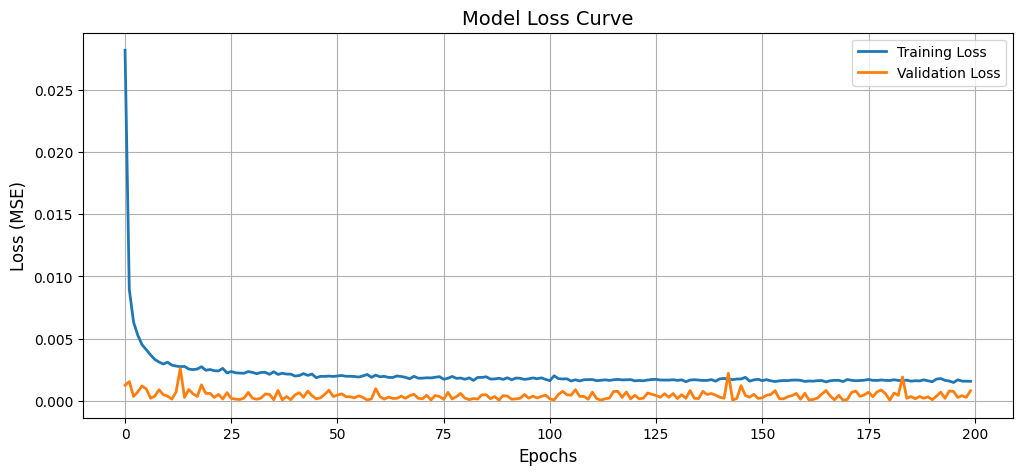

In [92]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)

plt.title('Model Loss Curve', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

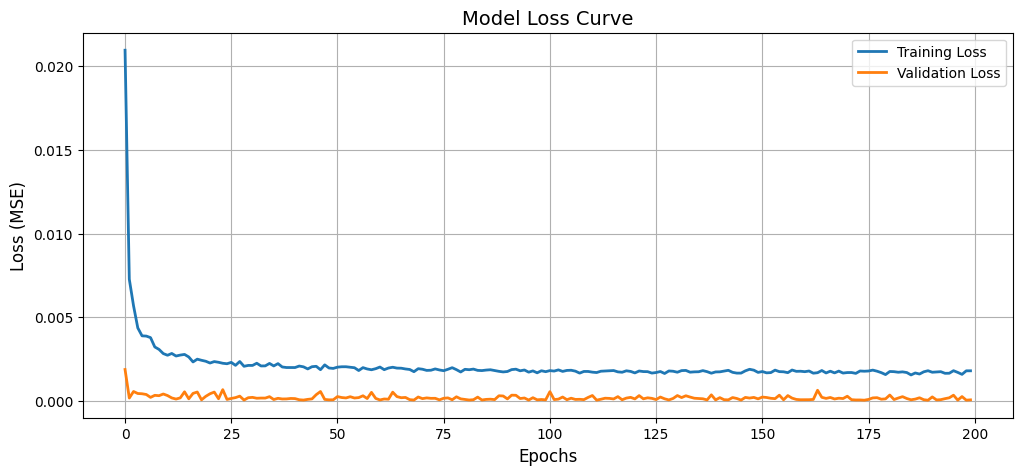

In [93]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(history1.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history1.history['val_loss'], label='Validation Loss', linewidth=2)

plt.title('Model Loss Curve', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

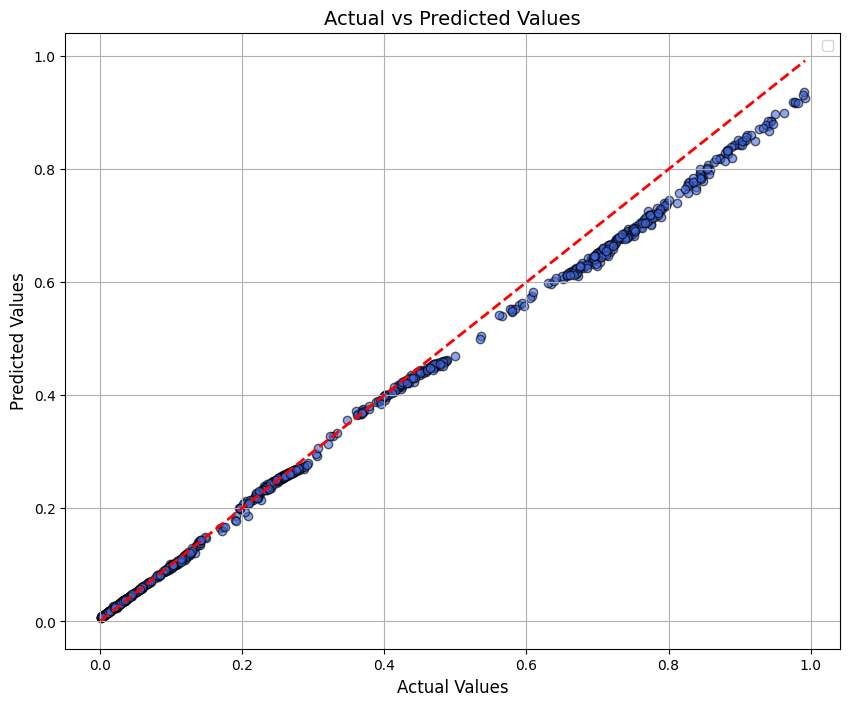

In [94]:
plt.figure(figsize=(10,8))
plt.scatter(ytest,y_pred,alpha=0.6,color="royalblue",edgecolor='k')

min_val=min(min(ytest),min(y_pred))
max_val = max(max(ytest),max(y_pred))

plt.plot([min_val,max_val],[min_val,max_val],color='red',linestyle='--',linewidth=2)
plt.title('Actual vs Predicted Values', fontsize=14)
plt.xlabel('Actual Values', fontsize=12)
plt.ylabel('Predicted Values', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

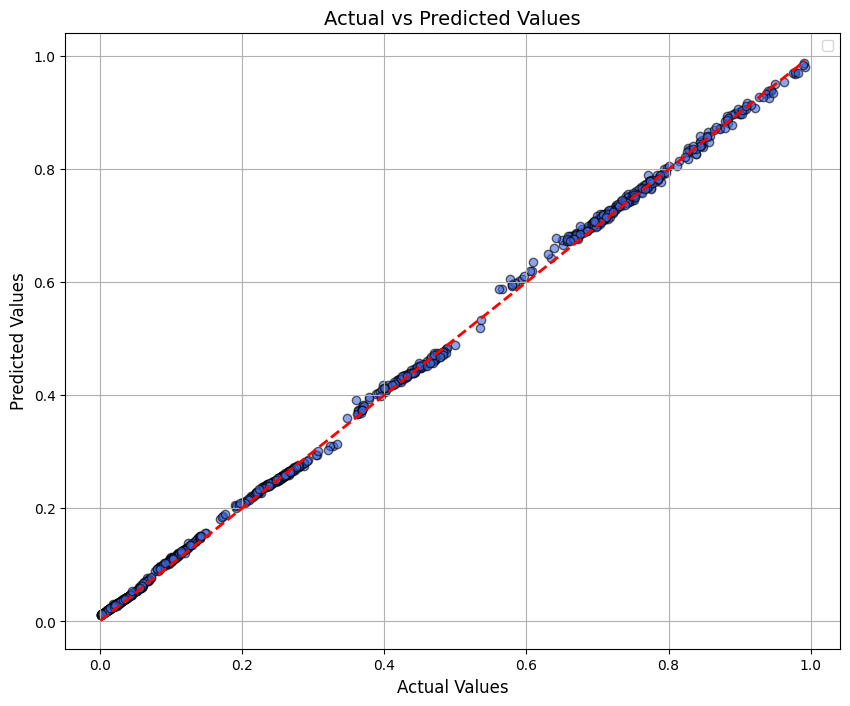

In [95]:
plt.figure(figsize=(10,8))
plt.scatter(ytest1,y_pred1,alpha=0.6,color="royalblue",edgecolor='k')

min_val1=min(min(ytest1),min(y_pred1))
max_val1 = max(max(ytest1),max(y_pred1))

plt.plot([min_val1,max_val1],[min_val1,max_val1],color='red',linestyle='--',linewidth=2)
plt.title('Actual vs Predicted Values', fontsize=14)
plt.xlabel('Actual Values', fontsize=12)
plt.ylabel('Predicted Values', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

In [96]:
y_pred_reshaped = y_pred.reshape(-1, 1)
y_pred_actual = scalery.inverse_transform(y_pred_reshaped)

In [97]:
y_pred_reshaped1 = y_pred1.reshape(-1, 1)
y_pred_actual1 = scalery1.inverse_transform(y_pred_reshaped1)

Hence,LSTM is the best one for the prediction

input values are "OPEN ","HIGH ","LOW ","PREV. CLOSE ","ltp ","52W H ","52W L ","VOLUME ","No of trades "

In [98]:
data = pd.read_csv(r"C:\Users\91984\Downloads\Quote-Equity-TCS-EQ-15-09-2025-to-15-10-2025.csv")

In [99]:
data

,Date,series,OPEN,HIGH,LOW,PREV. CLOSE,ltp,close,vwap,52W H,52W L,VOLUME,VALUE,No of trades
0,15-Oct-2025,EQ,"2,971.00","2,979.70","2,951.00","2,960.30","2,970.00","2,969.80","2,967.01","4,494.90","2,866.60","42,82,226","12,70,53,86,117.20","1,46,773"
1,14-Oct-2025,EQ,"3,021.00","3,027.20","2,955.50","3,007.20","2,960.00","2,960.30","2,976.34","4,494.90","2,866.60","36,11,416","10,74,87,94,587.50","1,83,673"
2,13-Oct-2025,EQ,"3,027.00","3,035.50","2,998.20","3,028.30","3,006.00","3,007.20","3,011.37","4,494.90","2,866.60","28,66,865","8,63,31,80,149.10","1,69,572"
3,10-Oct-2025,EQ,"3,050.00","3,070.00","3,006.90","3,061.70","3,028.00","3,028.30","3,032.16","4,494.90","2,866.60","88,17,365","26,73,56,29,672.60","2,44,153"
4,09-Oct-2025,EQ,"3,034.00","3,066.00","3,020.00","3,027.20","3,060.20","3,061.70","3,046.36","4,494.90","2,866.60","32,11,304","9,78,27,98,225.60","1,33,703"
5,08-Oct-2025,EQ,"2,975.00","3,043.00","2,968.00","2,973.70","3,031.50","3,027.20","3,024.78","4,494.90","2,866.60","41,21,889","12,46,78,11,108.50","1,54,336"
6,07-Oct-2025,EQ,"2,995.00","3,004.50","2,955.50","2,988.40","2,975.00","2,973.70","2,971.70","4,494.90","2,866.60","30,62,943","9,10,21,39,525.60","1,41,987"
7,06-Oct-2025,EQ,"2,902.00","2,993.60","2,895.60","2,901.90","2,988.00","2,988.40","2,959.88","4,494.90","2,866.60","21,12,774","6,25,35,56,716.30","1,00,920"
8,03-Oct-2025,EQ,"2,924.00","2,924.00","2,891.10","2,914.20","2,903.00","2,901.90","2,902.27","4,494.90","2,866.60","28,99,519","8,41,51,75,156.20","1,56,466"
9,01-Oct-2025,EQ,"2,891.00","2,924.80","2,866.60","2,888.40","2,915.10","2,914.20","2,897.26","4,494.90","2,866.60","19,52,902","5,65,80,70,903.00","1,24,217"


In [100]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Date           22 non-null     object
 1   series         22 non-null     object
 2   OPEN           22 non-null     object
 3   HIGH           22 non-null     object
 4   LOW            22 non-null     object
 5   PREV. CLOSE    22 non-null     object
 6   ltp            22 non-null     object
 7   close          22 non-null     object
 8   vwap           22 non-null     object
 9   52W H          22 non-null     object
 10  52W L          22 non-null     object
 11  VOLUME         22 non-null     object
 12  VALUE          22 non-null     object
 13  No of trades   22 non-null     object
dtypes: object(14)
memory usage: 2.5+ KB


In [101]:
numeric_columns = ["OPEN ","HIGH ","LOW ","PREV. CLOSE ","close ","ltp ","52W H ","52W L ","VOLUME ","No of trades "]

In [102]:
for i in numeric_columns:
    data[i]=data[i].str.replace(',','')
    data[i]=pd.to_numeric(data[i],errors='coerce')

In [103]:
data.drop(columns=['VALUE ','vwap ',"series ","PREV. CLOSE ","ltp ","52W H ","52W L ","No of trades "],inplace=True)

In [104]:
data['Date '] = pd.to_datetime(data['Date '])
data.set_index('Date ', inplace=True)

In [105]:
data

,OPEN,HIGH,LOW,close,VOLUME
Date,,,,,
2025-10-15,2971.0,2979.7,2951.0,2969.8,4282226
2025-10-14,3021.0,3027.2,2955.5,2960.3,3611416
2025-10-13,3027.0,3035.5,2998.2,3007.2,2866865
2025-10-10,3050.0,3070.0,3006.9,3028.3,8817365
2025-10-09,3034.0,3066.0,3020.0,3061.7,3211304
2025-10-08,2975.0,3043.0,2968.0,3027.2,4121889
2025-10-07,2995.0,3004.5,2955.5,2973.7,3062943
2025-10-06,2902.0,2993.6,2895.6,2988.4,2112774
2025-10-03,2924.0,2924.0,2891.1,2901.9,2899519


In [106]:
data = data.rename(columns={"Date ":"Date","OPEN ":"Open","HIGH ":'High',"LOW ":'Low','close ':"Close","VOLUME ":'Volume'})

In [107]:
data["Close"]

Date 
2025-10-15    2969.8
2025-10-14    2960.3
2025-10-13    3007.2
2025-10-10    3028.3
2025-10-09    3061.7
2025-10-08    3027.2
2025-10-07    2973.7
2025-10-06    2988.4
2025-10-03    2901.9
2025-10-01    2914.2
2025-09-30    2888.4
2025-09-29    2896.1
2025-09-26    2899.1
2025-09-25    2957.4
2025-09-24    3035.4
2025-09-23    3062.4
2025-09-22    3073.8
2025-09-19    3169.2
2025-09-18    3176.7
2025-09-17    3172.8
2025-09-16    3145.7
2025-09-15    3111.9
Name: Close, dtype: float64

In [108]:
X1=data.drop(columns ="Close")
value = scalerx.transform(X1)
value = np.reshape(value, (value.shape[0], 1, value.shape[1]))
predict = model_cnn.predict(value)
predict = np.array(predict).flatten()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step


In [109]:
value1 = scalerx1.transform(X1)
value1 = np.reshape(value1, (value1.shape[0], 1, value1.shape[1]))
predict1 = model_cnn1.predict(value1)
predict1 = np.array(predict1).flatten()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step


In [110]:
y1 = predict.reshape(-1, 1)
y1 = scalery.inverse_transform(y1)

In [111]:
y2 = predict1.reshape(-1, 1)
y2 = scalery1.inverse_transform(y2)

In [112]:
y2

array([[3037.9807],
       [3080.7678],
       [3091.2136],
       [3124.6555],
       [3107.5032],
       [3077.1921],
       [3061.8562],
       [3008.9817],
       [2982.9294],
       [2969.748 ],
       [2974.505 ],
       [2981.6716],
       [3006.978 ],
       [3082.408 ],
       [3113.547 ],
       [3124.7112],
       [3141.893 ],
       [3200.2327],
       [3219.0142],
       [3200.2017],
       [3174.9187],
       [3169.9653]], dtype=float32)

In [113]:
y2

array([[3037.9807],
       [3080.7678],
       [3091.2136],
       [3124.6555],
       [3107.5032],
       [3077.1921],
       [3061.8562],
       [3008.9817],
       [2982.9294],
       [2969.748 ],
       [2974.505 ],
       [2981.6716],
       [3006.978 ],
       [3082.408 ],
       [3113.547 ],
       [3124.7112],
       [3141.893 ],
       [3200.2327],
       [3219.0142],
       [3200.2017],
       [3174.9187],
       [3169.9653]], dtype=float32)

In [114]:
data

,Open,High,Low,Close,Volume
Date,,,,,
2025-10-15,2971.0,2979.7,2951.0,2969.8,4282226
2025-10-14,3021.0,3027.2,2955.5,2960.3,3611416
2025-10-13,3027.0,3035.5,2998.2,3007.2,2866865
2025-10-10,3050.0,3070.0,3006.9,3028.3,8817365
2025-10-09,3034.0,3066.0,3020.0,3061.7,3211304
2025-10-08,2975.0,3043.0,2968.0,3027.2,4121889
2025-10-07,2995.0,3004.5,2955.5,2973.7,3062943
2025-10-06,2902.0,2993.6,2895.6,2988.4,2112774
2025-10-03,2924.0,2924.0,2891.1,2901.9,2899519


In [115]:
y=data["Close"].values.reshape(-1, 1)

In [116]:
y

array([[2969.8],
       [2960.3],
       [3007.2],
       [3028.3],
       [3061.7],
       [3027.2],
       [2973.7],
       [2988.4],
       [2901.9],
       [2914.2],
       [2888.4],
       [2896.1],
       [2899.1],
       [2957.4],
       [3035.4],
       [3062.4],
       [3073.8],
       [3169.2],
       [3176.7],
       [3172.8],
       [3145.7],
       [3111.9]])

In [117]:
mse = mean_squared_error(y1, y)
r2 = r2_score(y1, y)

print(f" Mse : {mse:.6f}%")
print(f" r2 : {r2:.4f}")

 Mse : 39665.200777%
 r2 : -9.4529


In [118]:
mse = mean_squared_error(y2, y)
r2 = r2_score(y2, y)

print(f" Mse : {mse:.6f}%")
print(f" r2 : {r2:.4f}")

 Mse : 5559.300843%
 r2 : 0.0494


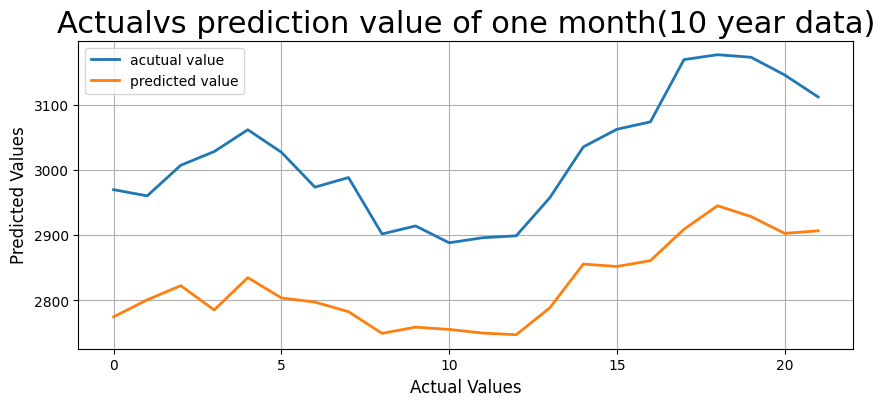

In [119]:
plt.figure(figsize=(10,4))
plt.plot(y,label="acutual value",linewidth=2)
plt.plot(y1,label="predicted value",linewidth=2)
plt.title("Actualvs prediction value of one month(10 year data)",fontsize=22)
plt.xlabel('Actual Values', fontsize=12)
plt.ylabel('Predicted Values', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

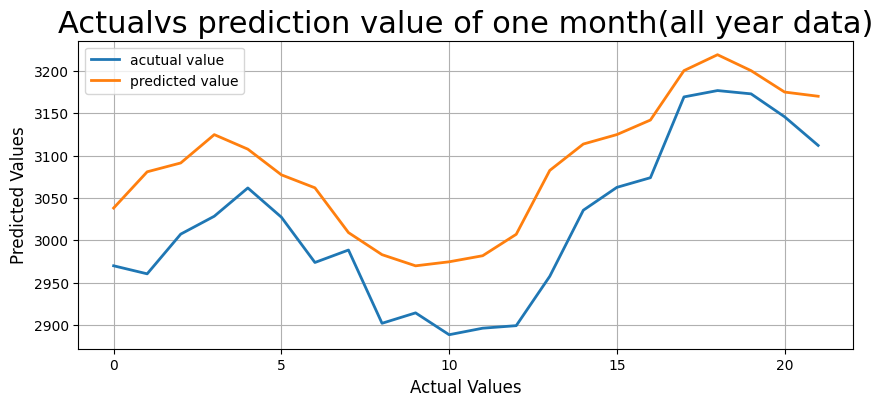

In [120]:
plt.figure(figsize=(10,4))
plt.plot(y,label="acutual value",linewidth=2)
plt.plot(y2,label="predicted value",linewidth=2)
plt.title("Actualvs prediction value of one month(all year data)",fontsize=22)
plt.xlabel('Actual Values', fontsize=12)
plt.ylabel('Predicted Values', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()